# Customer Churn — Exploratory Data Analysis

## Objective

Analyze customer behavior and identify the key factors associated with customer churn.

## Key Business Questions

1. What is the overall churn rate?
2. Which customer segments have the highest churn?
3. Does contract type influence churn?
4. Does tenure influence churn?
5. Do monthly charges influence churn?
6. Does payment method influence churn?
7. Which services are associated with higher/lower churn?
8. How much revenue is potentially at risk?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df =pd.read_csv("../data/processed/customer_churn_clean.csv")
df.shape

(7043, 21)

In [3]:
import os
print(os.getcwd())

c:\Customer-retention-churn-analytics\notebooks


## Overall Churn & KPIs

In [4]:
total_customers = df.shape[0]

churned_customers = (df["Churn"] == "Yes").sum()

retained_customers = (df["Churn"] == "No").sum()

churn_rate = churned_customers / total_customers * 100

print(f"Total Customers: {total_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Retained Customers: {retained_customers:,}")
print(f"Churn Rate: {churn_rate:.2f}%")

Total Customers: 7,043
Churned Customers: 1,869
Retained Customers: 5,174
Churn Rate: 26.54%


In [5]:
churn_counts = df["Churn"].value_counts()

churn_counts

Churn
No     5174
Yes    1869
Name: count, dtype: int64

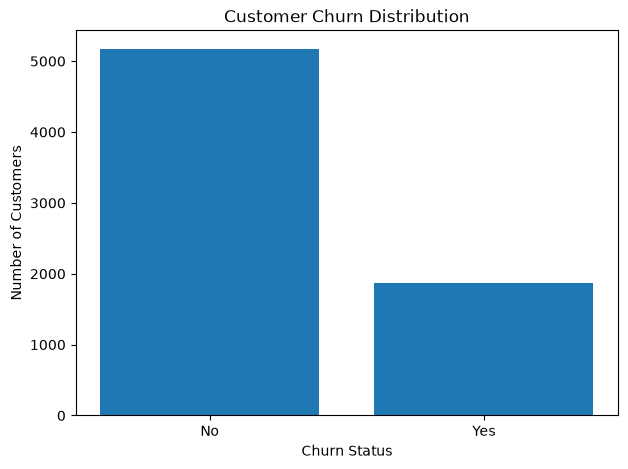

In [6]:
plt.figure(figsize=(7, 5))

plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

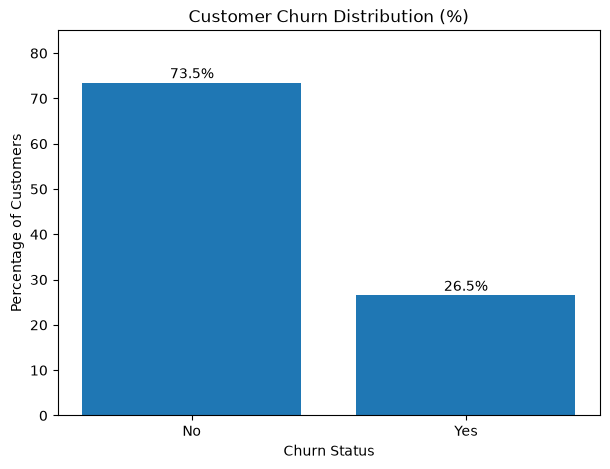

In [7]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

bars = plt.bar(
    churn_percentage.index,
    churn_percentage.values
)

plt.title("Customer Churn Distribution (%)")
plt.xlabel("Churn Status")
plt.ylabel("Percentage of Customers")

for bar, value in zip(bars, churn_percentage.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 85)

plt.show()

### Insight

Approximately 26.5% of customers have churned, while 73.5% have been retained. 
This indicates that churn represents a significant customer-retention challenge and provides 
a baseline against which different customer segments can be compared.

## Contract vs Churn

In [8]:
total_monthly_revenue = df["MonthlyCharges"].sum()

print(f"Total Monthly Revenue: ${total_monthly_revenue:,.2f}")

Total Monthly Revenue: $456,116.60


In [9]:
churned_monthly_revenue = df.loc[
    df["Churn"] == "Yes",
    "MonthlyCharges"
].sum()

print(
    f"Monthly Charges from Churned Customers: "
    f"${churned_monthly_revenue:,.2f}"
)

Monthly Charges from Churned Customers: $139,130.85


In [10]:
revenue_at_risk_pct = (
    churned_monthly_revenue /
    total_monthly_revenue
) * 100

print(f"Revenue associated with churned customers: {revenue_at_risk_pct:.2f}%")

Revenue associated with churned customers: 30.50%


In [11]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [12]:
contract_churn_counts = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_churn_counts

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [13]:
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

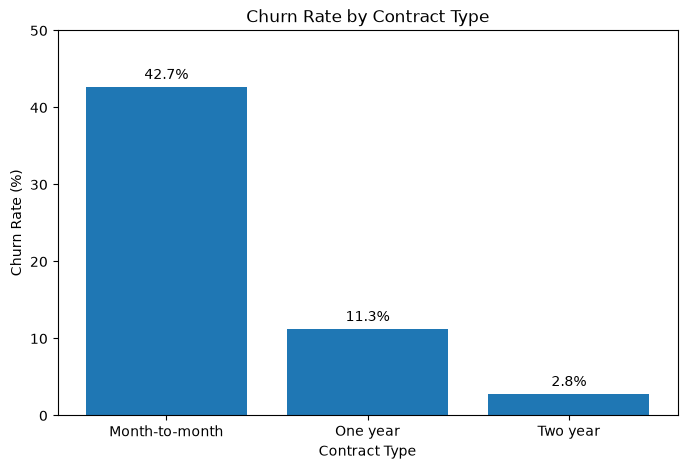

In [14]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    contract_churn_rate.index,
    contract_churn_rate.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, contract_churn_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 50)

plt.show()

In [15]:
overall_churn_rate = (df["Churn"] == "Yes").mean() * 100

contract_comparison = pd.DataFrame({
    "Churn Rate (%)": contract_churn_rate,
    "Difference from Overall (%)":
        contract_churn_rate - overall_churn_rate
})

contract_comparison

,Churn Rate (%),Difference from Overall (%)
Contract,,
Month-to-month,42.709677,16.172690
One year,11.269518,-15.267469
Two year,2.831858,-23.705129


### Insight — Contract Type

Contract type shows a strong association with customer churn.

Month-to-month customers have a substantially higher churn rate than the overall
customer base, while customers on one-year and two-year contracts show considerably
lower churn.

This suggests that longer-term contracts may be associated with stronger customer
retention, while month-to-month customers represent a high-priority segment for
retention initiatives.

However, this analysis shows an association rather than proving that contract type
causes churn.



## Tenure vs Churn

In [16]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [17]:
bins = [0, 12, 24, 36, 48, 60, 72]

labels = [
    "0-12 months",
    "13-24 months",
    "25-36 months",
    "37-48 months",
    "49-60 months",
    "61-72 months"
]

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["tenure", "tenure_group"]].head(15)

,tenure,tenure_group
0,1,0-12 months
1,34,25-36 months
2,2,0-12 months
3,45,37-48 months
4,2,0-12 months
5,8,0-12 months
6,22,13-24 months
7,10,0-12 months
8,28,25-36 months
9,62,61-72 months


In [18]:
df["tenure_group"].value_counts().sort_index()

tenure_group
0-12 months     2186
13-24 months    1024
25-36 months     832
37-48 months     762
49-60 months     832
61-72 months    1407
Name: count, dtype: int64

In [19]:
tenure_churn_rate = (
    df.groupby("tenure_group", observed=False)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

tenure_churn_rate

tenure_group
0-12 months     47.438243
13-24 months    28.710938
25-36 months    21.634615
37-48 months    19.028871
49-60 months    14.423077
61-72 months     6.609808
Name: Churn, dtype: float64

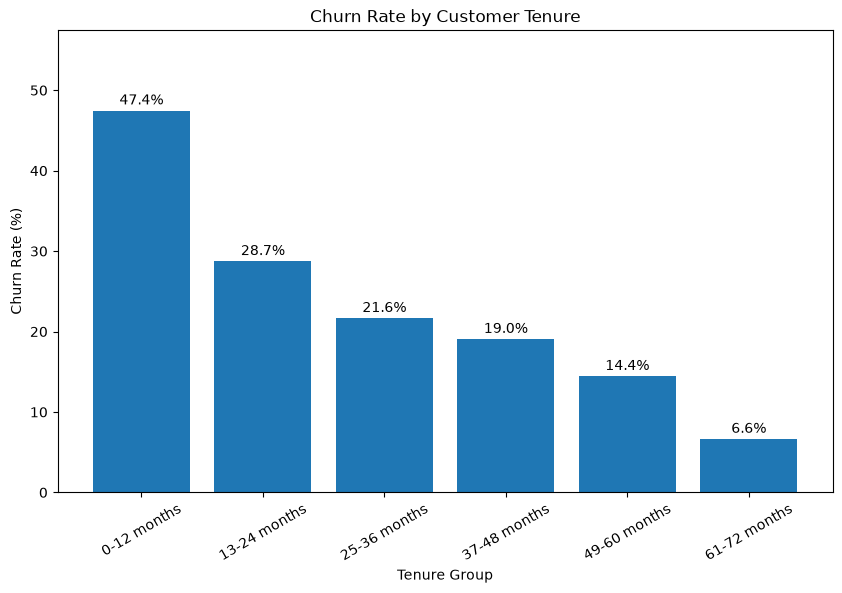

In [20]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    tenure_churn_rate.index.astype(str),
    tenure_churn_rate.values
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, tenure_churn_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{value:.1f}%",
        ha="center"
    )

plt.xticks(rotation=30)
plt.ylim(0, max(tenure_churn_rate.values) + 10)

plt.show()

In [21]:
overall_churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Overall churn rate: {overall_churn_rate:.2f}%")

Overall churn rate: 26.54%


In [22]:
tenure_analysis = pd.DataFrame({
    "Churn Rate (%)": tenure_churn_rate
})

tenure_analysis["Difference from Overall (%)"] = (
    tenure_analysis["Churn Rate (%)"] - overall_churn_rate
)

tenure_analysis

,Churn Rate (%),Difference from Overall (%)
tenure_group,,
0-12 months,47.438243,20.901256
13-24 months,28.710938,2.173950
25-36 months,21.634615,-4.902372
37-48 months,19.028871,-7.508116
49-60 months,14.423077,-12.113910
61-72 months,6.609808,-19.927179


In [23]:
highest_risk_tenure = tenure_churn_rate.idxmax()
highest_risk_rate = tenure_churn_rate.max()

print("Highest-risk tenure group:", highest_risk_tenure)
print(f"Churn rate: {highest_risk_rate:.2f}%")

Highest-risk tenure group: 0-12 months
Churn rate: 47.44%


### Business Interpretation

Customer tenure shows a clear association with churn. Customers with shorter
tenure tend to have higher churn rates, while customers who have remained with
the company for longer periods generally show lower churn.

The highest churn is observed among newer customers, indicating that the early
customer lifecycle may be a critical period for retention.

This suggests that the company should pay particular attention to onboarding,
early engagement, and proactive support during the first year of the customer
relationship.

The analysis identifies an association between tenure and churn and does not
by itself establish that shorter tenure causes churn.

## Monthly Charges vs Churn

In [24]:
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [26]:
charge_bins = [0, 40, 70, 100, float("inf")]

charge_labels = [
    "<$40",
    "$40-$70",
    "$70-$100",
    "$100+"
]

df["monthly_charge_group"] = pd.cut(
    df["MonthlyCharges"],
    bins=charge_bins,
    labels=charge_labels,
    include_lowest=True
)
df[["MonthlyCharges", "monthly_charge_group"]].head(15)

,MonthlyCharges,monthly_charge_group
0,29.85,<$40
1,56.95,$40-$70
2,53.85,$40-$70
3,42.30,$40-$70
4,70.70,$70-$100
5,99.65,$70-$100
6,89.10,$70-$100
7,29.75,<$40
8,104.80,$100+
9,56.15,$40-$70


In [27]:
df["monthly_charge_group"].value_counts().sort_index()

monthly_charge_group
<$40        1838
$40-$70     1622
$70-$100    2681
$100+        902
Name: count, dtype: int64

In [28]:
charge_churn_rate = (
    df.groupby(
        "monthly_charge_group",
        observed=False
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

charge_churn_rate

monthly_charge_group
<$40        11.643090
$40-$70     23.921085
$70-$100    37.821708
$100+       28.048780
Name: Churn, dtype: float64

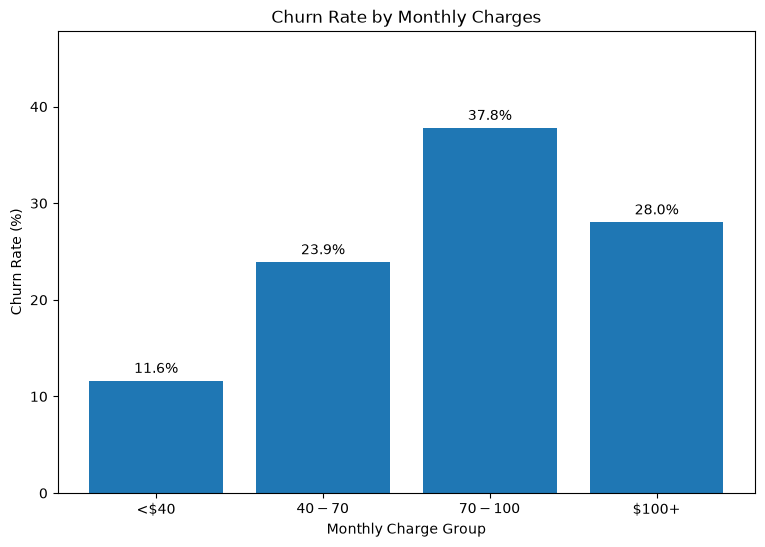

In [29]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    charge_churn_rate.index.astype(str),
    charge_churn_rate.values
)

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, charge_churn_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, max(charge_churn_rate.values) + 10)

plt.show()

In [30]:
charge_analysis = pd.DataFrame({
    "Churn Rate (%)": charge_churn_rate
})

charge_analysis["Difference from Overall (%)"] = (
    charge_analysis["Churn Rate (%)"] - overall_churn_rate
)

charge_analysis

,Churn Rate (%),Difference from Overall (%)
monthly_charge_group,,
<$40,11.643090,-14.893897
$40-$70,23.921085,-2.615902
$70-$100,37.821708,11.284721
$100+,28.048780,1.511793


In [31]:
highest_risk_charge_group = charge_churn_rate.idxmax()
highest_risk_charge_rate = charge_churn_rate.max()

print(
    "Highest-risk monthly charge group:",
    highest_risk_charge_group
)

print(
    f"Churn rate: {highest_risk_charge_rate:.2f}%"
)

Highest-risk monthly charge group: $70-$100
Churn rate: 37.82%


In [32]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "sum"]
)

,count,mean,sum
Churn,,,
No,5174,61.265124,316985.75
Yes,1869,74.441332,139130.85


In [33]:
charge_revenue_analysis = (
    df.groupby(
        "monthly_charge_group",
        observed=False
    )
    .agg(
        customers=("customerID", "count"),
        total_monthly_charges=("MonthlyCharges", "sum"),
        churn_rate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
)

charge_revenue_analysis

,customers,total_monthly_charges,churn_rate
monthly_charge_group,,,
<$40,1838,42044.85,11.643090
$40-$70,1622,90769.45,23.921085
$70-$100,2681,227089.60,37.821708
$100+,902,96212.70,28.048780


In [34]:
churned_charge_analysis = (
    df[df["Churn"] == "Yes"]
    .groupby(
        "monthly_charge_group",
        observed=False
    )["MonthlyCharges"]
    .agg(
        churned_customers="count",
        monthly_charges_at_risk="sum"
    )
)

churned_charge_analysis

,churned_customers,monthly_charges_at_risk
monthly_charge_group,,
<$40,214,5383.20
$40-$70,388,21256.65
$70-$100,1014,85926.90
$100+,253,26564.10


### Business Interpretation

Monthly charges show an association with customer churn, with higher-charge
customer segments generally exhibiting higher churn rates.

This indicates that customers with higher monthly charges may represent an
important retention segment. However, churn rate alone does not determine
financial impact, since the number of customers within each segment also
matters.

Therefore, both churn rate and monthly charges associated with churned
customers should be considered when prioritizing retention efforts.

## Payment Method vs Churn

In [37]:
df["PaymentMethod"].value_counts()


PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [38]:
payment_churn_counts = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

payment_churn_counts

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [39]:
payment_churn_rate = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

payment_churn_rate

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64

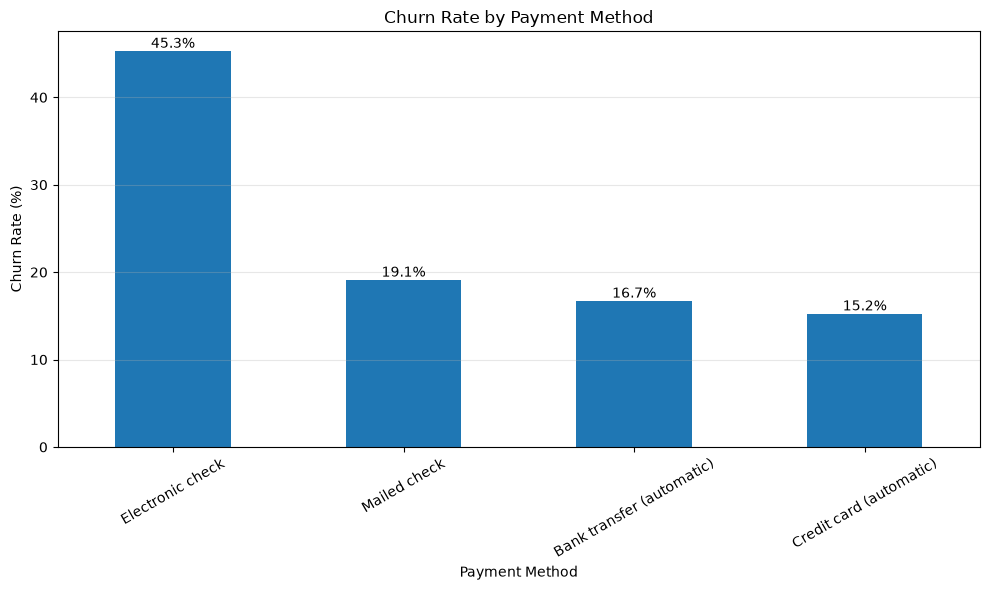

In [40]:
plt.figure(figsize=(10, 6))

ax = payment_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

In [41]:
payment_analysis = pd.DataFrame({
    "Churn Rate (%)": payment_churn_rate
})

payment_analysis["Difference from Overall (%)"] = (
    payment_analysis["Churn Rate (%)"] - overall_churn_rate
)

payment_analysis

,Churn Rate (%),Difference from Overall (%)
PaymentMethod,,
Electronic check,45.285412,18.748425
Mailed check,19.106700,-7.430287
Bank transfer (automatic),16.709845,-9.827143
Credit card (automatic),15.243101,-11.293886


In [42]:
highest_risk_payment = payment_churn_rate.idxmax()
highest_risk_payment_rate = payment_churn_rate.max()

print("Highest-risk payment method:", highest_risk_payment)
print("Churn rate:", round(highest_risk_payment_rate, 2), "%")

Highest-risk payment method: Electronic check
Churn rate: 45.29 %


In [43]:
payment_revenue_analysis = (
    df.groupby("PaymentMethod")
      .agg(
          customers=("customerID", "count"),
          total_monthly_charges=("MonthlyCharges", "sum"),
          churn_rate=("Churn", lambda x: (x == "Yes").mean() * 100)
      )
      .sort_values("churn_rate", ascending=False)
)

payment_revenue_analysis

,customers,total_monthly_charges,churn_rate
PaymentMethod,,,
Electronic check,2365,180345.00,45.285412
Mailed check,1612,70794.30,19.106700
Bank transfer (automatic),1544,103745.45,16.709845
Credit card (automatic),1522,101231.85,15.243101


In [44]:
churned_payment_analysis = (
    df[df["Churn"] == "Yes"]
      .groupby("PaymentMethod")["MonthlyCharges"]
      .agg(
          churned_customers="count",
          monthly_charges_at_risk="sum"
      )
      .sort_values("monthly_charges_at_risk", ascending=False)
)

churned_payment_analysis

,churned_customers,monthly_charges_at_risk
PaymentMethod,,
Electronic check,1071,84288.75
Bank transfer (automatic),258,20091.90
Credit card (automatic),232,17946.60
Mailed check,308,16803.60


In [45]:
payment_final_analysis = payment_revenue_analysis.join(
    churned_payment_analysis
)

payment_final_analysis

,customers,total_monthly_charges,churn_rate,churned_customers,monthly_charges_at_risk
PaymentMethod,,,,,
Electronic check,2365,180345.00,45.285412,1071,84288.75
Mailed check,1612,70794.30,19.106700,308,16803.60
Bank transfer (automatic),1544,103745.45,16.709845,258,20091.90
Credit card (automatic),1522,101231.85,15.243101,232,17946.60


### Business Interpretation

Payment method shows a strong association with customer churn in the dataset.

Customers using Electronic check have the highest churn rate at approximately 45.3%, substantially higher than Mailed check (19.1%), Bank transfer (16.7%), and Credit card (15.2%).

Electronic check customers also represent the largest financial exposure, with 1,071 churned customers associated with approximately $84,288.75 in monthly charges.

The two automatic payment methods show considerably lower churn rates, suggesting that payment method may be a useful variable for customer segmentation and retention analysis.

However, these results indicate association rather than causation. Further statistical analysis and predictive modeling will be used to investigate the relationship more rigorously.

## Customer Services vs Churn

In [46]:
service_columns = [
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

--- TechSupport ---
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

--- StreamingTV ---
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

--- StreamingMovies ---
StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dt

In [49]:

service_analysis = []

for col in service_columns:
    rates = (
        df.groupby(col)["Churn"]
          .apply(lambda x: (x == "Yes").mean() * 100)
    )
    
    for category, rate in rates.items():
        customer_count = (df[col] == category).sum()
        
        service_analysis.append({
            "Service": col,
            "Category": category,
            "Customers": customer_count,
            "Churn Rate (%)": rate
        })

service_analysis_df = pd.DataFrame(service_analysis)

service_analysis_df["Difference from Overall (%)"] = (
    service_analysis_df["Churn Rate (%)"] - overall_churn_rate
)

service_analysis_df

,Service,Category,Customers,Churn Rate (%),Difference from Overall (%)
0,InternetService,DSL,2421,18.959108,-7.577879
1,InternetService,Fiber optic,3096,41.892765,15.355778
2,InternetService,No,1526,7.404980,-19.132007
3,OnlineSecurity,No,3498,41.766724,15.229737
4,OnlineSecurity,No internet service,1526,7.404980,-19.132007
5,OnlineSecurity,Yes,2019,14.611194,-11.925793
6,OnlineBackup,No,3088,39.928756,13.391769
7,OnlineBackup,No internet service,1526,7.404980,-19.132007
8,OnlineBackup,Yes,2429,21.531494,-5.005493
9,DeviceProtection,No,3095,39.127625,12.590638


In [50]:
high_risk_services = (
    service_analysis_df
    .sort_values("Churn Rate (%)", ascending=False)
    .head(10)
)

high_risk_services

,Service,Category,Customers,Churn Rate (%),Difference from Overall (%)
1,InternetService,Fiber optic,3096,41.892765,15.355778
3,OnlineSecurity,No,3498,41.766724,15.229737
12,TechSupport,No,3473,41.635474,15.098487
6,OnlineBackup,No,3088,39.928756,13.391769
9,DeviceProtection,No,3095,39.127625,12.590638
18,StreamingMovies,No,2785,33.680431,7.143444
15,StreamingTV,No,2810,33.523132,6.986145
17,StreamingTV,Yes,2707,30.070188,3.533201
20,StreamingMovies,Yes,2732,29.941435,3.404448
11,DeviceProtection,Yes,2422,22.502064,-4.034923


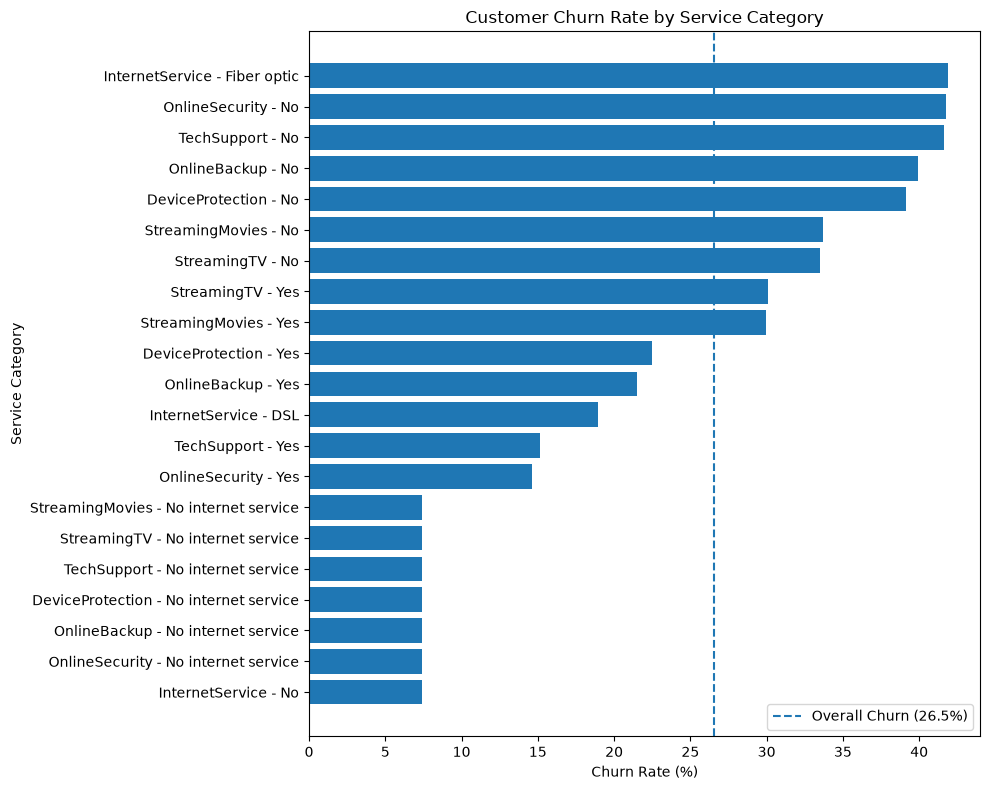

In [51]:
import matplotlib.pyplot as plt

plot_data = service_analysis_df.copy()

plot_data["Service Category"] = (
    plot_data["Service"] + " - " + plot_data["Category"]
)

plot_data = plot_data.sort_values(
    "Churn Rate (%)",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data["Service Category"],
    plot_data["Churn Rate (%)"]
)

plt.axvline(
    overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn ({overall_churn_rate:.1f}%)"
)

plt.xlabel("Churn Rate (%)")
plt.ylabel("Service Category")
plt.title("Customer Churn Rate by Service Category")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
service_impact_analysis = service_analysis_df.copy()

service_impact_analysis["Churned Customers"] = (
    service_impact_analysis["Customers"]
    * service_impact_analysis["Churn Rate (%)"]
    / 100
).round().astype(int)

service_impact_analysis = service_impact_analysis.sort_values(
    "Churned Customers",
    ascending=False
)

service_impact_analysis

,Service,Category,Customers,Churn Rate (%),Difference from Overall (%),Churned Customers
3,OnlineSecurity,No,3498,41.766724,15.229737,1461
12,TechSupport,No,3473,41.635474,15.098487,1446
1,InternetService,Fiber optic,3096,41.892765,15.355778,1297
6,OnlineBackup,No,3088,39.928756,13.391769,1233
9,DeviceProtection,No,3095,39.127625,12.590638,1211
15,StreamingTV,No,2810,33.523132,6.986145,942
18,StreamingMovies,No,2785,33.680431,7.143444,938
20,StreamingMovies,Yes,2732,29.941435,3.404448,818
17,StreamingTV,Yes,2707,30.070188,3.533201,814
11,DeviceProtection,Yes,2422,22.502064,-4.034923,545


In [53]:
service_financial_analysis = []

for col in service_columns:
    
    grouped = df.groupby(col)
    
    for category, group in grouped:
        
        churned_group = group[group["Churn"] == "Yes"]
        
        service_financial_analysis.append({
            "Service": col,
            "Category": category,
            "Customers": len(group),
            "Churn Rate (%)": (len(churned_group) / len(group)) * 100,
            "Churned Customers": len(churned_group),
            "Monthly Charges at Risk": churned_group["MonthlyCharges"].sum()
        })

service_financial_df = pd.DataFrame(
    service_financial_analysis
)

service_financial_df = service_financial_df.sort_values(
    "Monthly Charges at Risk",
    ascending=False
)

service_financial_df

,Service,Category,Customers,Churn Rate (%),Churned Customers,Monthly Charges at Risk
1,InternetService,Fiber optic,3096,41.892765,1297,114300.05
3,OnlineSecurity,No,3498,41.766724,1461,112762.75
12,TechSupport,No,3473,41.635474,1446,110709.80
6,OnlineBackup,No,3088,39.928756,1233,91873.85
9,DeviceProtection,No,3095,39.127625,1211,88752.25
17,StreamingTV,Yes,2707,30.070188,814,73664.85
20,StreamingMovies,Yes,2732,29.941435,818,73565.70
18,StreamingMovies,No,2785,33.680431,938,63263.55
15,StreamingTV,No,2810,33.523132,942,63164.40
11,DeviceProtection,Yes,2422,22.502064,545,48077.00


In [54]:
top_service_exposure = (
    service_financial_df
    .sort_values(
        "Monthly Charges at Risk",
        ascending=False
    )
    .head(10)
)

top_service_exposure

,Service,Category,Customers,Churn Rate (%),Churned Customers,Monthly Charges at Risk
1,InternetService,Fiber optic,3096,41.892765,1297,114300.05
3,OnlineSecurity,No,3498,41.766724,1461,112762.75
12,TechSupport,No,3473,41.635474,1446,110709.80
6,OnlineBackup,No,3088,39.928756,1233,91873.85
9,DeviceProtection,No,3095,39.127625,1211,88752.25
17,StreamingTV,Yes,2707,30.070188,814,73664.85
20,StreamingMovies,Yes,2732,29.941435,818,73565.70
18,StreamingMovies,No,2785,33.680431,938,63263.55
15,StreamingTV,No,2810,33.523132,942,63164.40
11,DeviceProtection,Yes,2422,22.502064,545,48077.00


In [55]:
service_final_analysis = (
    service_financial_df[
        service_financial_df["Category"] != "No internet service"
    ]
    .sort_values(
        "Churn Rate (%)",
        ascending=False
    )
)

service_final_analysis.head(10)

,Service,Category,Customers,Churn Rate (%),Churned Customers,Monthly Charges at Risk
1,InternetService,Fiber optic,3096,41.892765,1297,114300.05
3,OnlineSecurity,No,3498,41.766724,1461,112762.75
12,TechSupport,No,3473,41.635474,1446,110709.80
6,OnlineBackup,No,3088,39.928756,1233,91873.85
9,DeviceProtection,No,3095,39.127625,1211,88752.25
18,StreamingMovies,No,2785,33.680431,938,63263.55
15,StreamingTV,No,2810,33.523132,942,63164.40
17,StreamingTV,Yes,2707,30.070188,814,73664.85
20,StreamingMovies,Yes,2732,29.941435,818,73565.70
11,DeviceProtection,Yes,2422,22.502064,545,48077.00


### Business Interpretation

Customer service configuration shows a strong association with churn.

Customers using Fiber optic internet exhibit substantially higher churn than customers using DSL or customers without internet service. Among customers with internet service, those without additional services such as OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport generally show higher churn rates than customers who subscribe to these services.

The strongest patterns are observed for OnlineSecurity and TechSupport, where customers without these services have considerably higher churn rates than customers who have them.

These findings suggest that service configuration can be an important customer segmentation variable for retention analysis. Customers with high-risk service configurations may be suitable targets for proactive engagement, service education, or retention offers.

However, these results represent observational associations rather than evidence that the services themselves cause or prevent churn. Customer tenure, contract type, payment method, monthly charges, and other characteristics may also influence these relationships.

## Demographics & Household

In [56]:
demographic_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

for col in demographic_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- SeniorCitizen ---
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64


In [57]:
demographic_churn_rates = {}

for col in demographic_columns:
    demographic_churn_rates[col] = (
        df.groupby(col)["Churn"]
          .apply(lambda x: (x == "Yes").mean() * 100)
          .sort_values(ascending=False)
    )

for col, rates in demographic_churn_rates.items():
    print(f"\n--- {col} ---")
    print(rates.round(2))


--- gender ---
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

--- SeniorCitizen ---
SeniorCitizen
1    41.68
0    23.61
Name: Churn, dtype: float64

--- Partner ---
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

--- Dependents ---
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64


In [59]:
df["SeniorCitizenGroup"] = df["SeniorCitizen"].map({
    0: "Non-Senior Citizen",
    1: "Senior Citizen"
})
df[["SeniorCitizen", "SeniorCitizenGroup"]].head(10)

,SeniorCitizen,SeniorCitizenGroup
0,0,Non-Senior Citizen
1,0,Non-Senior Citizen
2,0,Non-Senior Citizen
3,0,Non-Senior Citizen
4,0,Non-Senior Citizen
5,0,Non-Senior Citizen
6,0,Non-Senior Citizen
7,0,Non-Senior Citizen
8,0,Non-Senior Citizen
9,0,Non-Senior Citizen


In [60]:
demographic_analysis = []

analysis_columns = {
    "gender": "Gender",
    "SeniorCitizenGroup": "Senior Citizen",
    "Partner": "Partner",
    "Dependents": "Dependents"
}

for col, label in analysis_columns.items():
    
    grouped = df.groupby(col)
    
    for category, group in grouped:
        
        churn_rate = (group["Churn"] == "Yes").mean() * 100
        
        demographic_analysis.append({
            "Factor": label,
            "Category": category,
            "Customers": len(group),
            "Churn Rate (%)": churn_rate
        })

demographic_analysis_df = pd.DataFrame(
    demographic_analysis
)

demographic_analysis_df["Difference from Overall (%)"] = (
    demographic_analysis_df["Churn Rate (%)"]
    - overall_churn_rate
)

demographic_analysis_df

,Factor,Category,Customers,Churn Rate (%),Difference from Overall (%)
0,Gender,Female,3488,26.920872,0.383884
1,Gender,Male,3555,26.160338,-0.376650
2,Senior Citizen,Non-Senior Citizen,5901,23.606168,-2.930819
3,Senior Citizen,Senior Citizen,1142,41.681261,15.144274
4,Partner,No,3641,32.957979,6.420991
5,Partner,Yes,3402,19.664903,-6.872084
6,Dependents,No,4933,31.279140,4.742153
7,Dependents,Yes,2110,15.450237,-11.086750


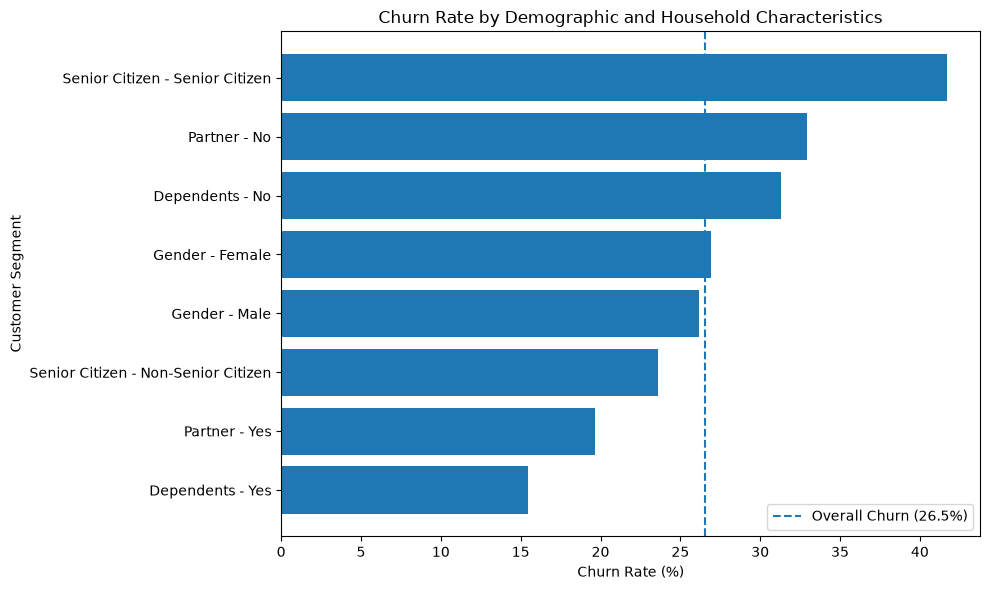

In [61]:
plot_data = demographic_analysis_df.copy()

plot_data["Factor Category"] = (
    plot_data["Factor"] + " - " + plot_data["Category"]
)

plot_data = plot_data.sort_values(
    "Churn Rate (%)",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Factor Category"],
    plot_data["Churn Rate (%)"]
)

plt.axvline(
    overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn ({overall_churn_rate:.1f}%)"
)

plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Segment")
plt.title("Churn Rate by Demographic and Household Characteristics")
plt.legend()
plt.tight_layout()
plt.show()

### Business Interpretation

Demographic and household characteristics show varying levels of association with customer churn.

Senior citizens generally exhibit higher churn than non-senior customers, while customers without a partner or dependents may also show different churn patterns compared with customers who have these household characteristics.

Gender differences, where present, should be interpreted cautiously and should not be treated as a major retention driver unless the observed difference is substantial and supported by statistical testing.

These characteristics can be useful for customer segmentation, but they should be considered alongside stronger behavioral and contractual factors such as tenure, contract type, payment method, monthly charges, and service configuration.

The observed differences represent associations rather than evidence that demographic characteristics cause customer churn.

## Total Charges & Customer Value

In [62]:
df["TotalCharges"].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [63]:
total_charges_comparison = (
    df.groupby("Churn")["TotalCharges"]
      .agg(["count", "mean", "median", "sum"])
)

total_charges_comparison

,count,mean,median,sum
Churn,,,,
No,5174,2549.911442,1679.525,13193241.8
Yes,1869,1531.796094,703.550,2862926.9


In [65]:
total_charge_bins = [0, 1000, 2500, 5000, 7500, float("inf")]

total_charge_labels = [
    "<$1K",
    "$1K-$2.5K",
    "$2.5K-$5K",
    "$5K-$7.5K",
    "$7.5K+"
]

df["total_charge_group"] = pd.cut(
    df["TotalCharges"],
    bins=total_charge_bins,
    labels=total_charge_labels,
    include_lowest=True
)

df[["TotalCharges", "total_charge_group"]].head(15)

,TotalCharges,total_charge_group
0,29.85,<$1K
1,1889.50,$1K-$2.5K
2,108.15,<$1K
3,1840.75,$1K-$2.5K
4,151.65,<$1K
5,820.50,<$1K
6,1949.40,$1K-$2.5K
7,301.90,<$1K
8,3046.05,$2.5K-$5K
9,3487.95,$2.5K-$5K


In [66]:
df["total_charge_group"].value_counts().sort_index()

total_charge_group
<$1K         2904
$1K-$2.5K    1642
$2.5K-$5K    1362
$5K-$7.5K     941
$7.5K+        194
Name: count, dtype: int64

In [70]:
total_charge_churn_rate = (
    df.groupby(
        "total_charge_group",
        observed=False
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

total_charge_churn_rate

total_charge_analysis = pd.DataFrame({
    "Churn Rate (%)": total_charge_churn_rate
})

total_charge_analysis["Difference from Overall (%)"] = (
    total_charge_analysis["Churn Rate (%)"]
    - overall_churn_rate
)

total_charge_analysis

,Churn Rate (%),Difference from Overall (%)
total_charge_group,,
<$1K,36.845730,10.308743
$1K-$2.5K,22.594397,-3.942590
$2.5K-$5K,19.897210,-6.639777
$5K-$7.5K,14.984060,-11.552928
$7.5K+,8.247423,-18.289564


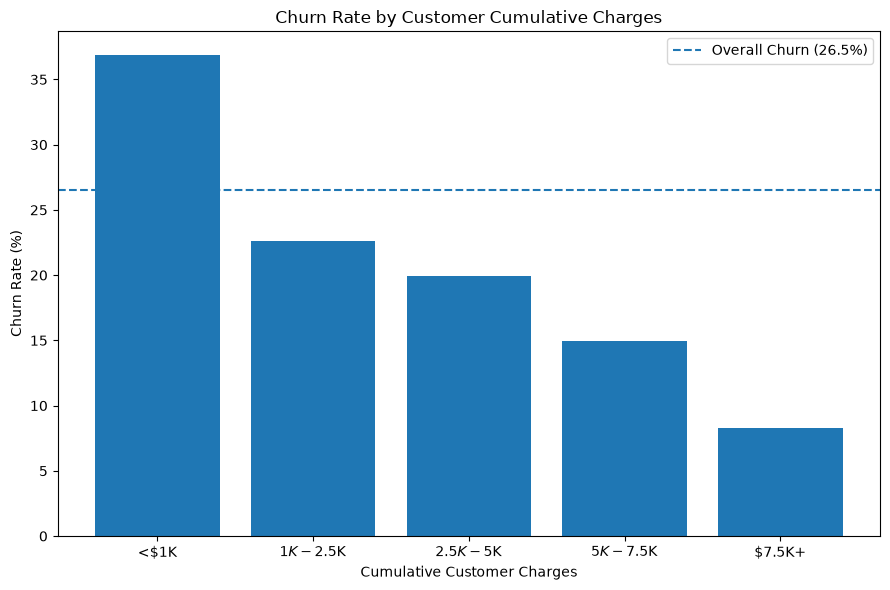

In [71]:
plt.figure(figsize=(9, 6))

plt.bar(
    total_charge_analysis.index.astype(str),
    total_charge_analysis["Churn Rate (%)"]
)

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn ({overall_churn_rate:.1f}%)"
)

plt.xlabel("Cumulative Customer Charges")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Customer Cumulative Charges")
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
total_charge_financial_analysis = (
    df.groupby(
        "total_charge_group",
        observed=False
    )
    .agg(
        customers=("customerID", "count"),
        total_monthly_charges=("MonthlyCharges", "sum"),
        churn_rate=("Churn", lambda x: (x == "Yes").mean() * 100),
        churned_customers=("Churn", lambda x: (x == "Yes").sum()),
        monthly_charges_at_risk=(
            "MonthlyCharges",
            lambda x: x[df.loc[x.index, "Churn"] == "Yes"].sum()
        )
    )
)

total_charge_financial_analysis

,customers,total_monthly_charges,churn_rate,churned_customers,monthly_charges_at_risk
total_charge_group,,,,,
<$1K,2904,139338.30,36.845730,1070,68389.35
$1K-$2.5K,1642,95461.85,22.594397,371,30403.50
$2.5K-$5K,1362,108922.65,19.897210,271,24247.30
$5K-$7.5K,941,90742.75,14.984060,141,14309.65
$7.5K+,194,21651.05,8.247423,16,1781.05


In [73]:
top_total_charge_exposure = (
    total_charge_financial_analysis
    .sort_values(
        "monthly_charges_at_risk",
        ascending=False
    )
)

top_total_charge_exposure

,customers,total_monthly_charges,churn_rate,churned_customers,monthly_charges_at_risk
total_charge_group,,,,,
<$1K,2904,139338.30,36.845730,1070,68389.35
$1K-$2.5K,1642,95461.85,22.594397,371,30403.50
$2.5K-$5K,1362,108922.65,19.897210,271,24247.30
$5K-$7.5K,941,90742.75,14.984060,141,14309.65
$7.5K+,194,21651.05,8.247423,16,1781.05


In [74]:
highest_risk_value_group = (
    total_charge_churn_rate.idxmax()
)

highest_risk_value_rate = (
    total_charge_churn_rate.max()
)

print(
    f"Highest-risk cumulative charge group: "
    f"{highest_risk_value_group}"
)

print(
    f"Churn rate: "
    f"{highest_risk_value_rate:.2f}%"
)

Highest-risk cumulative charge group: <$1K
Churn rate: 36.85%


### Business Interpretation

Cumulative customer charges show a clear association with churn.

Customers in lower cumulative-charge bands generally exhibit higher churn rates than customers with higher accumulated charges. This pattern is consistent with the earlier tenure analysis, as customers who have been with the company for shorter periods naturally accumulate fewer charges and also tend to experience higher churn.

From a retention perspective, lower cumulative-charge customers may therefore represent an important early-lifecycle risk segment. However, cumulative charges should not be interpreted as a direct cause of churn because the variable is strongly related to customer tenure and lifecycle stage.

The financial exposure analysis also demonstrates that churn risk should be evaluated alongside customer scale and monthly charges at risk. A segment with the highest churn rate is not necessarily the segment with the greatest financial exposure.

These findings reinforce the importance of combining customer behavior, lifecycle, contractual characteristics, and financial metrics when developing retention strategies.

## High-Risk Customer Segmentation

In [75]:
# Create a copy so the original analysis data remains safe
risk_df = df.copy()

# 1. Month-to-month contract indicator
risk_df["month_to_month_risk"] = (
    risk_df["Contract"] == "Month-to-month"
).astype(int)

# 2. Short-tenure indicator
risk_df["short_tenure_risk"] = (
    risk_df["tenure"] <= 12
).astype(int)

# 3. Electronic check indicator
risk_df["electronic_check_risk"] = (
    risk_df["PaymentMethod"] == "Electronic check"
).astype(int)

# 4. Higher monthly charge indicator
risk_df["high_monthly_charge_risk"] = (
    risk_df["MonthlyCharges"] >= 70
).astype(int)

# 5. No online security
risk_df["no_online_security_risk"] = (
    risk_df["OnlineSecurity"] == "No"
).astype(int)

# 6. No technical support
risk_df["no_tech_support_risk"] = (
    risk_df["TechSupport"] == "No"
).astype(int)

risk_df[
    [
        "month_to_month_risk",
        "short_tenure_risk",
        "electronic_check_risk",
        "high_monthly_charge_risk",
        "no_online_security_risk",
        "no_tech_support_risk"
    ]
].head()

,month_to_month_risk,short_tenure_risk,electronic_check_risk,high_monthly_charge_risk,no_online_security_risk,no_tech_support_risk
0,1,1,1,0,1,1
1,0,0,0,0,0,1
2,1,1,0,0,0,1
3,0,0,0,0,0,0
4,1,1,1,1,1,1


In [76]:
risk_columns = [
    "month_to_month_risk",
    "short_tenure_risk",
    "electronic_check_risk",
    "high_monthly_charge_risk",
    "no_online_security_risk",
    "no_tech_support_risk"
]

risk_df["risk_factor_count"] = risk_df[risk_columns].sum(axis=1)

risk_df[
    [
        "customerID",
        "risk_factor_count"
    ]
].head(15)

,customerID,risk_factor_count
0,7590-VHVEG,5
1,5575-GNVDE,1
2,3668-QPYBK,3
3,7795-CFOCW,0
4,9237-HQITU,6
5,9305-CDSKC,6
6,1452-KIOVK,4
7,6713-OKOMC,3
8,7892-POOKP,4
9,6388-TABGU,1


In [77]:
risk_distribution = (
    risk_df["risk_factor_count"]
    .value_counts()
    .sort_index()
)

risk_distribution

risk_factor_count
0    1073
1    1072
2    1317
3     995
4    1121
5     977
6     488
Name: count, dtype: int64

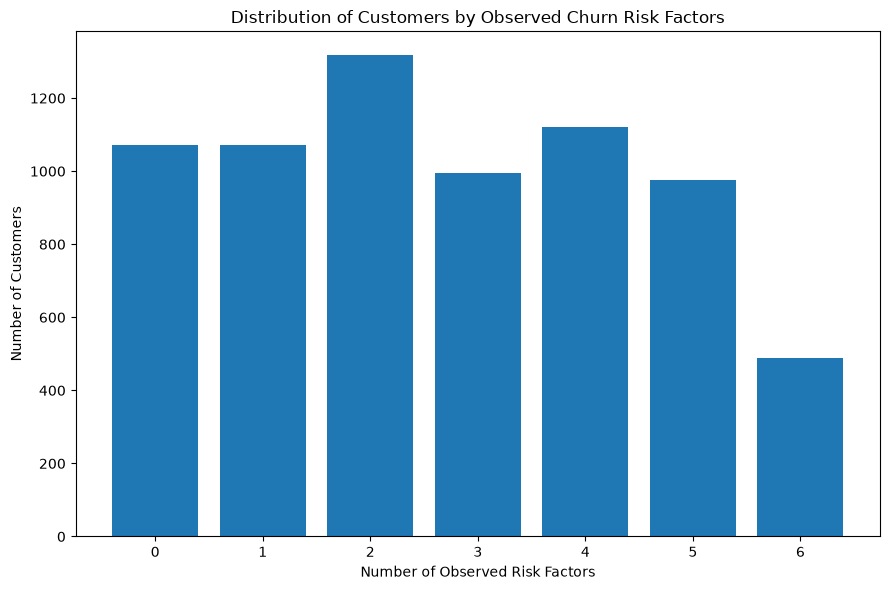

In [78]:
plt.figure(figsize=(9, 6))

plt.bar(
    risk_distribution.index.astype(str),
    risk_distribution.values
)

plt.xlabel("Number of Observed Risk Factors")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customers by Observed Churn Risk Factors")

plt.tight_layout()
plt.show()

In [79]:
risk_churn_analysis = (
    risk_df.groupby("risk_factor_count")
    .agg(
        customers=("customerID", "count"),
        churned_customers=(
            "Churn",
            lambda x: (x == "Yes").sum()
        ),
        churn_rate=(
            "Churn",
            lambda x: (x == "Yes").mean() * 100
        ),
        total_monthly_charges=(
            "MonthlyCharges",
            "sum"
        )
    )
)

risk_churn_analysis["difference_from_overall"] = (
    risk_churn_analysis["churn_rate"]
    - overall_churn_rate
)

risk_churn_analysis

,customers,churned_customers,churn_rate,total_monthly_charges,difference_from_overall
risk_factor_count,,,,,
0,1073,13,1.211556,31637.50,-25.325431
1,1072,66,6.156716,69914.75,-20.380271
2,1317,182,13.819286,81706.30,-12.717701
3,995,220,22.110553,73592.10,-4.426434
4,1121,449,40.053524,82936.90,13.516537
5,977,576,58.955988,75880.45,32.419001
6,488,363,74.385246,40448.60,47.848259


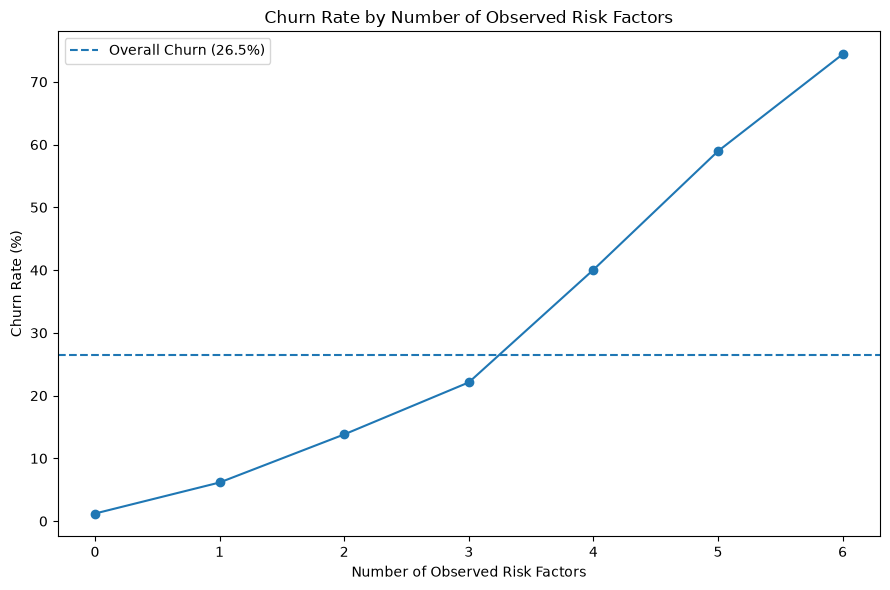

In [80]:
plt.figure(figsize=(9, 6))

plt.plot(
    risk_churn_analysis.index,
    risk_churn_analysis["churn_rate"],
    marker="o"
)

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn ({overall_churn_rate:.1f}%)"
)

plt.xlabel("Number of Observed Risk Factors")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Number of Observed Risk Factors")
plt.xticks(risk_churn_analysis.index)
plt.legend()
plt.tight_layout()
plt.show()

In [81]:
def classify_risk(count):
    if count <= 1:
        return "Low"
    elif count <= 3:
        return "Medium"
    else:
        return "High"

risk_df["risk_segment"] = (
    risk_df["risk_factor_count"]
    .apply(classify_risk)
)

In [86]:
risk_segment_analysis = (
    risk_df.groupby("risk_segment")
    .agg(
        customers=("customerID", "count"),
        churned_customers=(
            "Churn",
            lambda x: (x == "Yes").sum()
        ),
        churn_rate=(
            "Churn",
            lambda x: (x == "Yes").mean() * 100
        ),
        total_monthly_charges=(
            "MonthlyCharges",
            "sum"
        ),
        monthly_charges_at_risk=(
            "MonthlyCharges",
            lambda x: x[
                risk_df.loc[x.index, "Churn"] == "Yes"
            ].sum()
        )
    )
)

risk_segment_analysis = (
    risk_segment_analysis
    .reindex(["Low", "Medium", "High"])
)

risk_segment_analysis

risk_segment_analysis["at_risk_charge_share (%)"] = (
    risk_segment_analysis["monthly_charges_at_risk"]
    / risk_segment_analysis["total_monthly_charges"]
    * 100
)

risk_segment_analysis

,customers,churned_customers,churn_rate,total_monthly_charges,monthly_charges_at_risk,at_risk_charge_share (%)
risk_segment,,,,,,
Low,2145,79,3.682984,101552.25,5115.25,5.037062
Medium,2312,402,17.387543,155298.40,25925.40,16.693926
High,2586,1388,53.673627,199265.95,108090.20,54.244190


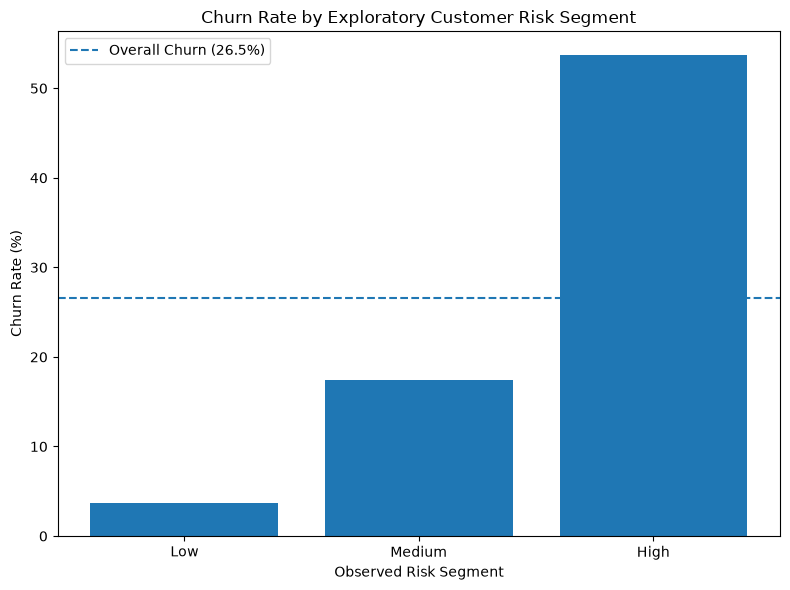

In [84]:
plt.figure(figsize=(8, 6))

plt.bar(
    risk_segment_analysis.index,
    risk_segment_analysis["churn_rate"]
)

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    label=f"Overall Churn ({overall_churn_rate:.1f}%)"
)

plt.xlabel("Observed Risk Segment")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Exploratory Customer Risk Segment")
plt.legend()
plt.tight_layout()
plt.show()

In [85]:
highest_exposure_segment = (
    risk_segment_analysis[
        "monthly_charges_at_risk"
    ].idxmax()
)

highest_exposure_value = (
    risk_segment_analysis[
        "monthly_charges_at_risk"
    ].max()
)

highest_churn_segment = (
    risk_segment_analysis[
        "churn_rate"
    ].idxmax()
)

highest_churn_rate = (
    risk_segment_analysis[
        "churn_rate"
    ].max()
)

print(
    f"Highest churn segment: {highest_churn_segment}"
)

print(
    f"Highest churn rate: {highest_churn_rate:.2f}%"
)

print(
    f"Highest financial exposure segment: "
    f"{highest_exposure_segment}"
)

print(
    f"Monthly charges at risk: "
    f"${highest_exposure_value:,.2f}"
)

Highest churn segment: High
Highest churn rate: 53.67%
Highest financial exposure segment: High
Monthly charges at risk: $108,090.20


### Business Interpretation

Combining multiple churn-associated characteristics provides a more actionable view of customer risk than analyzing individual variables in isolation.

Customers exhibiting a greater number of observed risk characteristics can be grouped into progressively higher-risk segments. These characteristics include month-to-month contracts, shorter tenure, Electronic check payment, higher monthly charges, and absence of selected support or security services.

The risk segmentation also highlights an important business distinction between churn probability and financial exposure. A segment with the highest churn rate may not necessarily represent the greatest financial exposure if its customer base is relatively small.

This exploratory risk score is not a predictive machine-learning model and should not be interpreted as a probability of churn. Instead, it provides an interpretable segmentation framework that can help identify customer groups for deeper statistical analysis and subsequent predictive modeling.

The observed relationships indicate association rather than causation.